# Do it yourself: Bayesian yes–no decisions with binary data

The first five steps handed you sliders on a machine someone else built. This one
hands you the **parts**. You write the half-dozen lines at its heart; the plots are
already wired to whatever you return.

Every model so far lived on a continuous effect size Δ. But Step 2 never did — it was
about a **binary** verdict (positive / negative, correct / wrong) and a **base rate**,
and it was the one step that never got its Bayesian answer. Here is that answer.

The object is a **classifier** with a single unknown: its true success rate **p**. You
watch it decide *n* labelled cases, it gets *k* right, and you want the honest
distribution over *p* — then a decision. The whole pipeline you met in steps 3–5
returns, on new data:

> *posterior* ~ *prior* × *likelihood*  →  *expected utility*  →  *act*

Two things make binary data the right place to *code* this by hand, rather than drag a
slider over it:

| what changes | why it helps |
|---|---|
| *p* is a probability, so its **entire** universe is the interval [0, 1] | the prior, likelihood and posterior are just arrays over a fine grid — no tails to truncate, no axis bounds to guess (the thing that made Step 4's plane fiddly) |
| the Beta–Binomial pair is **conjugate** | the exact posterior is known on paper — so you can *check* your numerical answer against ground truth before trusting it anywhere else |

So your grid is a *numerical* answer to a problem that also has an *analytic* one. That
is not busywork — it is the only honest way to learn a method: practise it where the
answer key exists, then carry it where it doesn't.

## 0 · Setup

The grid, the data, and the prior. The prior is exactly Step 2's base rate, written as a
**Beta(α, β)** — a handful of imaginary cases you saw before the real ones (echoing
Step 4's κ₀: a prior priced in pseudo-observations, here the pseudo-count α + β).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist        # the answer key, used once below

# --- the grid: the whole trick lives here -------------------------------
# p is a probability, so its entire universe is [0, 1]. Slice it finely.
N  = 1001
p  = np.linspace(0.0, 1.0, N)        # the rate axis: every candidate p
dp = p[1] - p[0]

# --- the data: one classifier, scored on a labelled set -----------------
n = 40        # cases seen
k = 27        # times it was right     (try other (n, k) once it runs)

# --- the prior = Step 2's base rate, as a Beta --------------------------
# mean alpha/(alpha+beta); "worth" alpha+beta imaginary cases.
# Lax = small, opinionated = large.
alpha, beta = 6.0, 4.0

Matplotlib is building the font cache; this may take a moment.


### Plotting helpers (provided)

These are the plots the cells below are wired to. You never need to touch them — they
just draw whatever arrays you return.

In [2]:
def plot_curve(p, y, title, color="#C45A26"):
    """A single curve over [0, 1] — used to eyeball the prior and the likelihood."""
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(p, y, lw=2.4, color=color)
    ax.fill_between(p, y, color=color, alpha=0.10)
    ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
    ax.set_xlabel("p  (success rate)"); ax.set_title(title)
    fig.tight_layout(); plt.show()


def plot_three(p, prior_d, like_d, posterior):
    """The Step-4 triptych on [0, 1]: prior, likelihood, posterior together."""
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(p, prior_d,  lw=2.2, color="#7C7563", label="prior")
    ax.plot(p, like_d,   lw=2.2, color="#355E92", label="likelihood")
    ax.plot(p, posterior, lw=3.0, color="#C45A26", label="posterior")
    ax.fill_between(p, posterior, color="#C45A26", alpha=0.10)
    ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
    ax.set_xlabel("p  (success rate)"); ax.set_ylabel("density")
    ax.set_title("prior  ·  likelihood  ·  posterior")
    ax.legend(frameon=False)
    fig.tight_layout(); plt.show()


def plot_overlay(p, posterior, post_exact):
    """Your numerical posterior against the closed-form Beta — should coincide."""
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(p, posterior,  lw=4.0, color="#C45A26", alpha=0.55,
            label="numerical (your grid)")
    ax.plot(p, post_exact, lw=1.6, ls="--", color="#1A1A1A",
            label="analytic  Beta(α+k, β+n−k)")
    ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
    ax.set_xlabel("p  (success rate)"); ax.set_ylabel("density")
    ax.set_title("numerical posterior  vs  analytic Beta")
    ax.legend(frameon=False)
    fig.tight_layout(); plt.show()

## 1 · The prior, on the grid

A Beta density is just *p<sup>α−1</sup>(1−p)<sup>β−1</sup>* up to a constant. You don't
need the constant — the normaliser you write in cell 3 divides it out anyway.

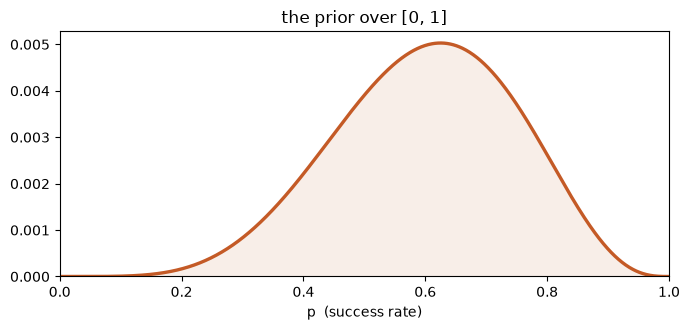

In [3]:
def prior_kernel(p, alpha, beta):
    """Un-normalised Beta density on the grid: p**(alpha-1) * (1-p)**(beta-1).

    in : p (N,) in [0, 1];  alpha > 0, beta > 0
    out: (N,) non-negative, NOT yet normalised
    """
    return p**(alpha - 1) * (1 - p)**(beta - 1)


plot_curve(p, prior_kernel(p, alpha, beta), "the prior over [0, 1]")

## 2 · The likelihood, read as a function of *p*

Same Binomial as Step 1's machine, but now *p* is the variable and the data *(n, k)* are
fixed. Drop the *n-choose-k* constant: it is identical for every *p* and washes out in
normalisation.

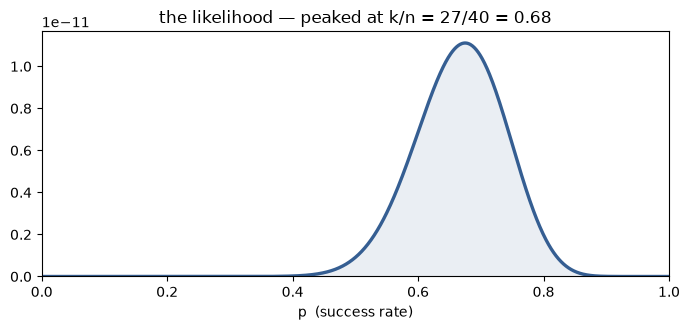

In [4]:
def likelihood(p, n, k):
    """The data's vote for each p: p**k * (1-p)**(n-k).

    in : p (N,);  n trials, k successes
    out: (N,) non-negative (un-normalised)
    """
    return p**k * (1 - p)**(n - k)


plot_curve(p, likelihood(p, n, k),
           f"the likelihood — peaked at k/n = {k}/{n} = {k/n:.2f}", color="#355E92")

## 3 · Normalise — *the one hard line*

Step 4 called normalisation *the* main challenge of Bayesian inference. On a 1-D grid it
shrinks to a single Riemann sum: divide the curve by its own area. Write it once; use it
for prior, likelihood and posterior alike.

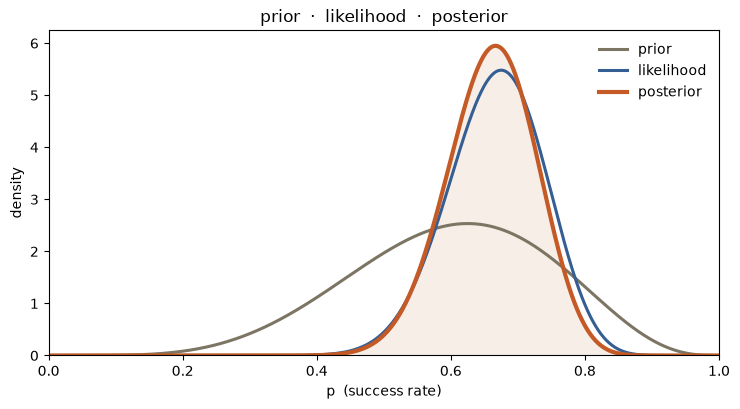

In [5]:
def normalize(density, dp):
    """Scale a non-negative curve so it integrates to 1 over the grid.

    in : density (N,) >= 0;  dp = grid spacing
    out: (N,) with  out.sum() * dp == 1
    """
    return density / (density.sum() * dp)


# Bayes as multiplication, then one normalisation:
prior_d    = normalize(prior_kernel(p, alpha, beta), dp)
like_d     = normalize(likelihood(p, n, k), dp)
posterior  = normalize(prior_kernel(p, alpha, beta) * likelihood(p, n, k), dp)

plot_three(p, prior_d, like_d, posterior)   # prior · likelihood · posterior

## 4 · Check it against the answer key

Because Beta is conjugate to the Binomial, the exact posterior is, with no grid at all,
**Beta(α+k, β+n−k)**. Overlay it on your numerical curve: they should lie on top of each
other. If they don't, the bug is in `normalize`.

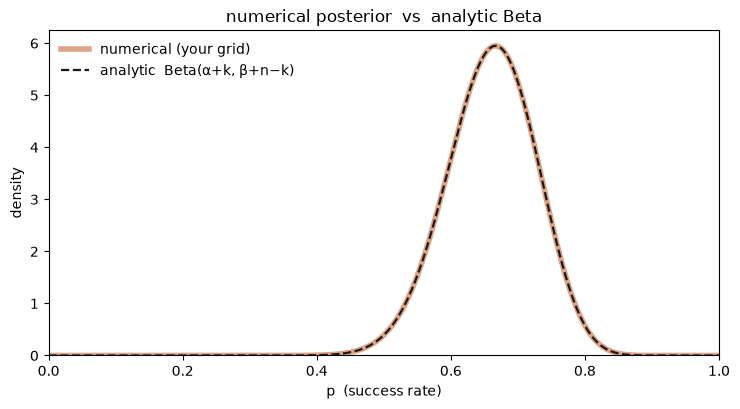

numerical and analytic posteriors agree to 1e-3 ✓


In [6]:
post_exact = beta_dist(alpha + k, beta + n - k).pdf(p)   # closed form — no sum

plot_overlay(p, posterior, post_exact)                 # numerical vs analytic
assert np.allclose(posterior, post_exact, atol=1e-3)
print("numerical and analytic posteriors agree to 1e-3 ✓")

## 5 · From belief to act

Step 5's rule, on new data: pair the posterior with a reward and act on **expected
utility**. The decision is *bet* (act on a case) or *fold* (do nothing, a guaranteed 0).
Acting on a true positive earns `GAIN`; acting on a false positive costs `COST`. The grid
sum below is the *general* recipe — it works for any reward; this one happens to be simple
enough to also have a closed form, which is a second thing to check against.

In [7]:
GAIN = 1.0     # reward for acting on a true positive
COST = 2.0     # penalty for acting on a false positive
               # (folding is always 0; missing or skipping a negative cost 0 too)

def expected_utility_act(p, posterior, dp):
    """E[U(act)] = integral of [GAIN*p - COST*(1-p)] * posterior(p) dp.

    The per-case payoff of acting is GAIN when the case is a true positive
    (probability p) and -COST when it is a false positive (probability 1-p).
    Averaging it against the posterior is one weighted sum over the grid.
    """
    payoff = GAIN * p - COST * (1 - p)
    return np.sum(payoff * posterior) * dp


def decide(p, posterior, dp):
    """Bet (act) iff E[U(act)] > 0, else fold. Return (value, 'bet' | 'fold')."""
    value = expected_utility_act(p, posterior, dp)
    return value, ("bet" if value > 0 else "fold")


value, action = decide(p, posterior, dp)

# closed-form check: E[U] is linear in p, so it only needs the posterior mean.
E_p         = (alpha + k) / (alpha + beta + n)
closed_form = GAIN * E_p - COST * (1 - E_p)

print(f"E[U(act)]   = {value:+.4f}   ->   {action.upper()}")
print(f"closed form = {closed_form:+.4f}   (E[p] = {E_p:.4f})")
print(f"break-even rate  COST/(GAIN+COST) = {COST/(GAIN+COST):.4f}")

E[U(act)]   = -0.0200   ->   FOLD
closed form = -0.0200   (E[p] = 0.6600)
break-even rate  COST/(GAIN+COST) = 0.6667


## 6 · Why this was a toy

*No code — a thought experiment.*

Your grid spent N = 1001 cells on **one** rate. A model with *d* unknown rates needs
N<sup>d</sup> cells: for *d* = 5 that is 1001<sup>5</sup> ≈ 1e15 — already impossible. The
line you wrote in cell 3 is a friendly toy here and a brick wall there. That wall is the
whole reason MCMC and variational inference exist.

## Questions to answer

- Set `alpha, beta = 1, 1` — the flat prior. Is it as innocent here as it looked in
  Step 3? What rate does it secretly bet on before any data, and what does it claim about
  a rate of 0 or 1?
- Push the prior hard toward a wrong rate (`alpha, beta = 40, 4`) and watch the posterior
  pull away from `k / n` — then raise *n*. Which one wins, and at what point? (You priced
  this in pseudo-observations: α + β imaginary cases against *n* real ones.)
- Make the success genuinely rare — a low-mean prior, say `alpha, beta = 2, 40`. How much
  data does it take to move the posterior, and how does that compare with the certainty
  the same *k / n* would suggest on its own?
- Raise `COST` until `decide` folds. Does it fold sooner when the posterior is wide
  (small *n*) than when it is sharp? Tie the break-even back to the threshold
  `COST / (GAIN + COST)` and to Step 5.

## The moral (write your own)

- **TODO —** the same four boxes (prior, likelihood, posterior, decision) you dragged
  through five steps are, on binary data, ten lines of array arithmetic. State that in
  your own words.
- **TODO —** conjugacy gave a free answer key — twice (the posterior *and* the decision).
  Say what the grid is *for*, then, if the closed form was there all along.
- **TODO —** the grid that solved this in one line is hopeless in five dimensions — the
  one honest sentence about what the rest of Bayesian computation is *for*.

| you wrote | it is the same as… | seen before in |
|---|---|---|
| `prior_kernel` | belief before data, priced in pseudo-cases (α + β) | Step 4 · κ₀ |
| `normalize` | making the area 1 — "the main challenge" | Step 4 |
| `expected_utility_act` / `decide` | act to maximise E[U] | Step 5 |
| **TODO** | **TODO — fill in once you've run it** | — |